<a href="https://colab.research.google.com/github/venkatasivasai44/Classification-of-Ai-vs-Real-Images/blob/main/ViT_novality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install timm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Importing Required Libraries
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [ ]:
#Defining Training Configuration
DATASET_ROOT = "/content/drive/MyDrive/Final_dataset/Final_dataset"
BATCH_SIZE = 32
EPOCHS = 20
LR = 1e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

assert os.path.exists(DATASET_ROOT)
assert os.path.exists(os.path.join(DATASET_ROOT, "train"))
assert os.path.exists(os.path.join(DATASET_ROOT, "val"))

print("✅ Dataset verified")

✅ Dataset verified


In [ ]:
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.1, 0.1, 0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

val_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

In [ ]:
train_ds = datasets.ImageFolder(
    os.path.join(DATASET_ROOT, "train"),
    transform=train_tf
)

val_ds = datasets.ImageFolder(
    os.path.join(DATASET_ROOT, "val"),
    transform=val_tf
)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True
)

val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False
)

NUM_CLASSES = len(train_ds.classes)
print("Classes:", train_ds.classes)

Classes: ['abstract_ai', 'abstract_real', 'doodle_ai', 'doodle_real', 'scribble_ai', 'scribble_real']


In [ ]:
class MultiClassViT(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.vit = timm.create_model(
            "vit_base_patch16_224",
            pretrained=True,
            num_classes=0,
            global_pool=""
        )

        embed_dim = self.vit.num_features
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        tokens = self.vit.forward_features(x)   # [B, 197, D]
        cls_token = tokens[:, 0]
        patch_tokens = tokens[:, 1:]

        logits = self.classifier(cls_token)

        # Patch-consistency regularization
        patch_var = patch_tokens.var(dim=1).mean(dim=1)

        return logits, patch_var

In [ ]:
criterion = nn.CrossEntropyLoss()

def total_loss(logits, labels, patch_var):
    return criterion(logits, labels) + 0.1 * torch.mean(patch_var)

model = MultiClassViT(NUM_CLASSES).to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=LR)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [ ]:
!pip install torchinfo

In [ ]:
!pip install torchinfo

from torchinfo import summary
import pandas as pd

# get model summary
model_summary = summary(
    model,
    input_size=(1,3,224,224),
    verbose=0
)

layers = []

for layer in model_summary.summary_list:
    layers.append([
        layer.class_name,
        str(layer.output_size),
        layer.num_params
    ])

# create dataframe
table = pd.DataFrame(
    layers,
    columns=["Layer", "Output Shape", "Parameters"]
)

print(table)

                 Layer      Output Shape  Parameters
0        MultiClassViT            [1, 6]    85803270
1    VisionTransformer                []    85798656
2           PatchEmbed     [1, 196, 768]      590592
3               Conv2d  [1, 768, 14, 14]      590592
4             Identity     [1, 196, 768]           0
..                 ...               ...         ...
258            Dropout     [1, 197, 768]           0
259           Identity     [1, 197, 768]           0
260           Identity     [1, 197, 768]           0
261          LayerNorm     [1, 197, 768]        1536
262             Linear            [1, 6]        4614

[263 rows x 3 columns]


In [ ]:
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0

    for imgs, labels in train_loader:
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        logits, patch_var = model(imgs)
        loss = total_loss(logits, labels, patch_var)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {epoch_loss/len(train_loader):.4f}")

Epoch 1/20 | Loss: 0.4757
Epoch 2/20 | Loss: 0.2374
Epoch 3/20 | Loss: 0.1180
Epoch 4/20 | Loss: 0.1036
Epoch 5/20 | Loss: 0.1573
Epoch 6/20 | Loss: 0.1054
Epoch 7/20 | Loss: 0.0910
Epoch 8/20 | Loss: 0.0957
Epoch 9/20 | Loss: 0.1537
Epoch 10/20 | Loss: 0.3280
Epoch 11/20 | Loss: 0.0999
Epoch 12/20 | Loss: 0.0759
Epoch 13/20 | Loss: 0.0666
Epoch 14/20 | Loss: 0.0749
Epoch 15/20 | Loss: 0.0957
Epoch 16/20 | Loss: 0.0736
Epoch 17/20 | Loss: 0.0812
Epoch 18/20 | Loss: 0.0703
Epoch 19/20 | Loss: 0.0585
Epoch 20/20 | Loss: 0.0383


In [ ]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(DEVICE)

        logits, _ = model(imgs)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        y_true.extend(labels.numpy())
        y_pred.extend(preds)

In [ ]:
print("\n6-CLASS CLASSIFICATION REPORT")
print(classification_report(
    y_true,
    y_pred,
    target_names=train_ds.classes
))


6-CLASS CLASSIFICATION REPORT
               precision    recall  f1-score   support

  abstract_ai       0.98      0.98      0.98        92
abstract_real       0.98      0.97      0.98       132
    doodle_ai       0.96      0.99      0.98       100
  doodle_real       0.97      0.96      0.96       100
  scribble_ai       0.98      0.95      0.97        62
scribble_real       0.97      0.99      0.98       100

     accuracy                           0.97       586
    macro avg       0.97      0.97      0.97       586
 weighted avg       0.97      0.97      0.97       586



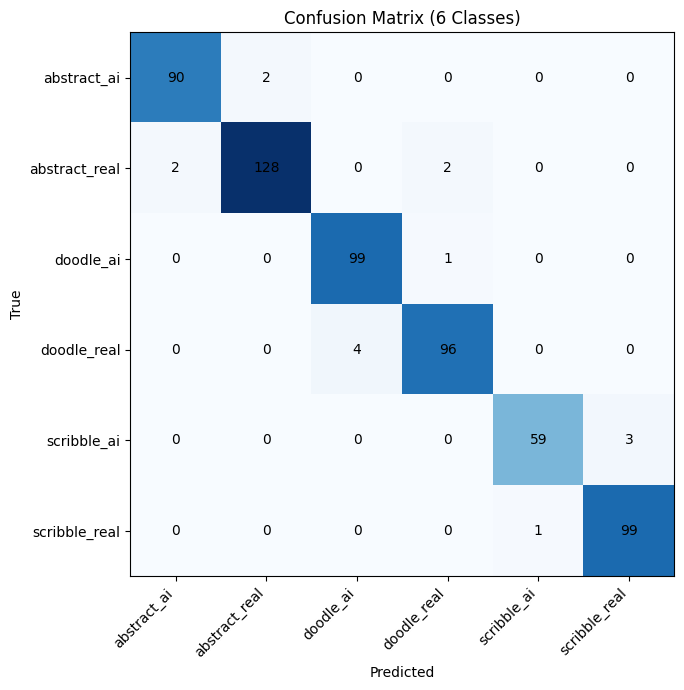

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 7))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix (6 Classes)")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.xticks(
    range(NUM_CLASSES),
    train_ds.classes,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(NUM_CLASSES),
    train_ds.classes
)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [ ]:
SAVE_DIR = "/content/drive/MyDrive/Final_dataset/Final_dataset/saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)

SAVE_PATH = os.path.join(SAVE_DIR, "vit_multiclass_6class.pth")

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "class_names": train_ds.classes,
        "epochs": EPOCHS,
        "learning_rate": LR,
        "architecture": "ViT-Base-Patch16",
        "task": "6-class artwork classification"
    },
    SAVE_PATH
)

print(f"✅ Model saved at:\n{SAVE_PATH}")

✅ Model saved at:
/content/drive/MyDrive/Final_dataset/Final_dataset/saved_models/vit_multiclass_6class.pth
